# Trustworthy Machine Learning: Bias & Reliability Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("adult.csv")

cols = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df.columns = cols
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df = df.replace("?", np.nan)
df = df.dropna()

In [4]:
num_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [10]:
y_pred = model.predict(X_test_scaled)

print("Overall Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Overall Accuracy: 0.8178352395159953
Confusion Matrix:
 [[4274  259]
 [ 840  660]]


In [11]:
df_test = X_test.copy()

df_test["actual"] = y_test
df_test["predicted"] = y_pred

print(df_test["sex"].value_counts())

sex
1    4157
0    1876
Name: count, dtype: int64


In [12]:
male = df_test[df_test["sex"] == 1]
female = df_test[df_test["sex"] == 0]

male_acc = accuracy_score(male["actual"], male["predicted"])
female_acc = accuracy_score(female["actual"], female["predicted"])

print("Male Accuracy:", male_acc)
print("Female Accuracy:", female_acc)

Male Accuracy: 0.7810921337503007
Female Accuracy: 0.8992537313432836


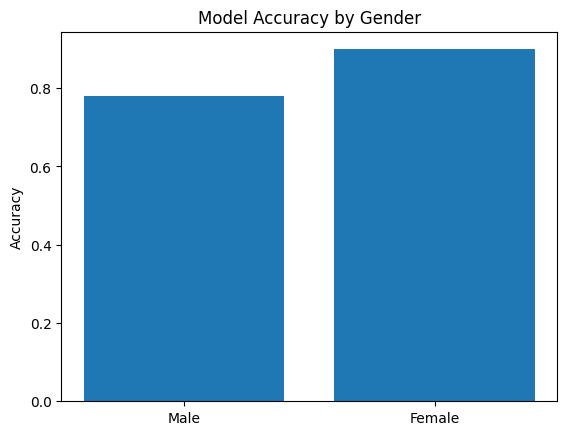

In [14]:
plt.bar(["Male", "Female"], [male_acc, female_acc])
plt.title("Model Accuracy by Gender")
plt.ylabel("Accuracy")
plt.show()

In [15]:
print("Male Confusion Matrix:\n", confusion_matrix(male["actual"], male["predicted"]))
print("Female Confusion Matrix:\n", confusion_matrix(female["actual"], female["predicted"]))

Male Confusion Matrix:
 [[2638  240]
 [ 670  609]]
Female Confusion Matrix:
 [[1636   19]
 [ 170   51]]


In [16]:
print("Male Report:\n", classification_report(male["actual"], male["predicted"]))
print("Female Report:\n", classification_report(female["actual"], female["predicted"]))

Male Report:
               precision    recall  f1-score   support

           0       0.80      0.92      0.85      2878
           1       0.72      0.48      0.57      1279

    accuracy                           0.78      4157
   macro avg       0.76      0.70      0.71      4157
weighted avg       0.77      0.78      0.77      4157

Female Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      1655
           1       0.73      0.23      0.35       221

    accuracy                           0.90      1876
   macro avg       0.82      0.61      0.65      1876
weighted avg       0.88      0.90      0.88      1876



In [18]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Logistic Regression Accuracy: 0.8178352395159953
Decision Tree Accuracy: 0.8015912481352561


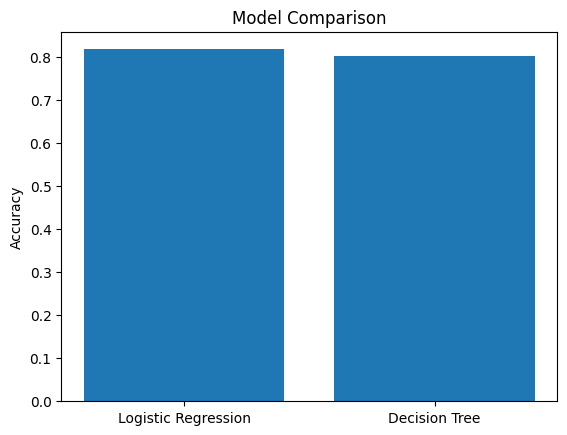

In [19]:
models = ["Logistic Regression", "Decision Tree"]
scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, dt_pred)
]

import matplotlib.pyplot as plt

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## Model Comparison

I compared Logistic Regression with a Decision Tree model to see how performance differs. 

Logistic Regression performed more consistently, while Decision Tree showed variation. This comparison helps understand model behavior better rather than relying on a single approach.